---
title: Hurricane Maria rainfall over Puerto Rico (MAAG)
author: Harsha R. Hampapura
date: 2026-06-23
---

## Hurricane Maria rainfall over Puerto Rico (MAAG)

This notebook illustrates how to make diagnostic plots using the **MAAG**
dataset hosted on NCAR's [Geoscience Data Exchange (GDEX)](https://gdex.ucar.edu/datasets/d010077/).

The **Mesoamerica Affinity Group (MAAG)** dataset is a 2-week
*convection-permitting* simulation of **Hurricane Maria (2017)** run with the
Model for Prediction Across Scales – Atmosphere (**MPAS-A**) on a novel
variable-resolution **15→3 km** mesh centered over Central America and the
Caribbean, forced by ERA5. It is described in
[Núñez Ocasio et al. (2026, BAMS)](https://doi.org/10.1175/BAMS-D-25-0023.1).

:::{note} Native mesh vs. regridded product
MPAS-A writes output on an unstructured Voronoi **mesh**. GDEX archives both the
native-mesh output *and* a copy **regridded to a regular 0.25° latitude–longitude
grid** (27 isobaric levels). We use the **regridded product** here so we can rely
on the usual `xarray` + Cartopy workflow; the native mesh would require a mesh-aware
tool such as [`uxarray`](https://uxarray.readthedocs.io/).
:::

## What this notebook does

We reproduce a scaled-down version of **Fig. 3** of Núñez Ocasio et al. (2026):
the **accumulated rainfall as Hurricane Maria crossed Puerto Rico, 19–21 Sep 2017**.
Because the regridded domain is regional and only ~2 weeks of hourly data, the
whole workflow runs comfortably on a single machine — **no Dask cluster required**.

In [1]:
# Imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

## Accessing MAAG through GDEX

Like other GDEX collections, MAAG is served through a [kerchunk](https://fsspec.github.io/kerchunk/)
reference layer over the underlying NetCDF files, so a single
`xr.open_dataset(..., engine="kerchunk")` call exposes the regridded archive as a
virtual `xarray.Dataset`.

:::{tip} Getting the reference URL
On the [d010077 dataset page](https://gdex.ucar.edu/datasets/d010077/), search for
a variable to get its kerchunk reference filename, then paste it below.
:::

In [4]:
# GDEX kerchunk reference for the MAAG regridded (deg.25) product, served over HTTPS
kerchunk_url = "https://data.gdex.ucar.edu/d010077/kerchunk/deg.25_diag-remote-https.json"
print(kerchunk_url)

https://data.gdex.ucar.edu/d010077/kerchunk/deg.25_diag-remote-https.json


In [5]:
ds = xr.open_dataset(kerchunk_url, engine="kerchunk")

# Inspect what's actually in the regridded product: dims, coords, and variable names
print("Dimensions:", dict(ds.sizes))
print("Coordinates:", list(ds.coords))
print("Data variables:")
for v in ds.data_vars:
    print(f"  {v:20s} {ds[v].dims}  {ds[v].attrs.get('long_name','')}")
ds

Dimensions: {'xtime': 361, 'lat': 720, 'lon': 1440, 't_iso_levels': 27, 'u_iso_levels': 27, 'z_iso_levels': 27}
Coordinates: ['xtime', 'lat', 'lon', 't_iso_levels', 'u_iso_levels', 'z_iso_levels']
Data variables:
  dtheta_dt_mp_isobaric ('xtime', 'lat', 'lon', 't_iso_levels')  Potential temperature heating rate from microphysics interpolated to isobaric surfaces defined in t_iso_levels
  hfx                  ('xtime', 'lat', 'lon')  upward heat flux at the surface
  mslp                 ('xtime', 'lat', 'lon')  Mean sea-level pressure
  olrtoa               ('xtime', 'lat', 'lon')  all-sky top-of-atmosphere outgoing longwave radiation flux
  quantization_info    ('xtime',)  
  qv_isobaric          ('xtime', 'lat', 'lon', 't_iso_levels')  Water vapor mixing ratio interpolated to isobaric surfaces defined in t_iso_levels
  rainc                ('xtime', 'lat', 'lon')  accumulated convective precipitation
  rainnc               ('xtime', 'lat', 'lon')  accumulated total grid-scale precipi

<xarray.Dataset> Size: 509GB
Dimensions:                (xtime: 361, lat: 720, lon: 1440, t_iso_levels: 27,
                            u_iso_levels: 27, z_iso_levels: 27)
Coordinates:
  * xtime                  (xtime) datetime64[ns] 3kB 2017-09-15 ... 2017-09-30
  * lat                    (lat) float64 6kB -89.88 -89.62 ... 89.62 89.88
  * lon                    (lon) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
  * t_iso_levels           (t_iso_levels) float32 108B 1e+04 1.25e+04 ... 1e+05
  * u_iso_levels           (u_iso_levels) float32 108B 1e+04 1.25e+04 ... 1e+05
  * z_iso_levels           (z_iso_levels) float32 108B 1e+04 1.25e+04 ... 1e+05
Data variables: (12/29)
    dtheta_dt_mp_isobaric  (xtime, lat, lon, t_iso_levels) float32 40GB ...
    hfx                    (xtime, lat, lon) float32 1GB ...
    mslp                   (xtime, lat, lon) float32 1GB ...
    olrtoa                 (xtime, lat, lon) float32 1GB ...
    quantization_info      (xtime) object 3kB ...
    qv_isobaric            (xtime, lat, lon, t_iso_levels) float32 40GB ...
    ...                     ...
    uzonal_850hPa          (xtime, lat, lon) float32 1GB ...
    uzonal_isobaric        (xtime, lat, lon, u_iso_levels) float32 40GB ...
    w_700hPa               (xtime, lat, lon) float32 1GB ...
    w_850hPa               (xtime, lat, lon) float32 1GB ...
    w_isobaric             (xtime, lat, lon, u_iso_levels) float32 40GB ...
    z_isobaric             (xtime, lat, lon, z_iso_levels) float32 40GB ...
Attributes: (12/125)
    CDI:                                    Climate Data Interface version 2....
    CDO:                                    Climate Data Operators version 2....
    Conventions:                            MPAS
    NCO:                                    netCDF Operators version 5.3.1 (H...
    camdim1:                                4
    cdo_openmp_thread_number:               120
    ...                                     ...
    on_a_sphere:                            YES
    parent_id:                              e24ogs8q85\n
    source:                                 MPAS
    sphere_radius:                          6371229.0
    x_period:                               0.0
    y_period:                               0.0

:::{seealso} Dataset documentation
- [Variable.pdf](https://osdata.gdex.ucar.edu/web/datasets/d010077/docs/Variable.pdf) — full variable list for both the native-grid and post-processed files (long names, units, levels).
- [README.txt](https://osdata.gdex.ucar.edu/web/datasets/d010077/docs/README.txt) — file types, the conservative regridding to ~30 km, and recipes for derived fields (e.g. total rainfall = `rainc + rainnc`).
:::

## Accumulated rainfall during Maria's passage

MPAS accumulates precipitation from the start of the run, split into convective
(`rainc`) and grid-scale (`rainnc`) components. On this convection-permitting
mesh the resolved `rainnc` dominates, and total precipitation is their sum.

To get the rainfall that fell during a window, we subtract the accumulation at
the start of the window from the accumulation at the end. Hurricane Maria's eye
crossed Puerto Rico on **20 Sep 2017**, so we use a **19–21 Sep** window.

In [17]:
%%time
total_accum = ds["rainc"] + ds["rainnc"]      # mm, accumulated since run start

t0 = np.datetime64("2017-09-19T00")           # Maria approaching Puerto Rico
t1 = np.datetime64("2017-09-21T23")           # after the eye has passed

storm_total = (total_accum.sel(xtime=t1) - total_accum.sel(xtime=t0)).compute()

# The grid is 0–360°; shift to −180..180 so the Caribbean has negative lons
storm_total = storm_total.assign_coords(lon=((storm_total.lon + 180) % 360) - 180).sortby("lon")

# The global field is NaN outside the MAAG footprint — sanity-check over Puerto Rico
pr = storm_total.sel(lat=slice(16.5, 19.5), lon=slice(-69, -63))
print(f"Puerto Rico window — max storm total: {float(pr.max()):.0f} mm")
storm_total

Puerto Rico window — max storm total: 421 mm
CPU times: user 101 ms, sys: 12.1 ms, total: 113 ms
Wall time: 629 ms


<xarray.DataArray (lat: 720, lon: 1440)> Size: 4MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Attributes:
    quantization:      quantization_info
    quantization_nsd:  7
    units:             mm

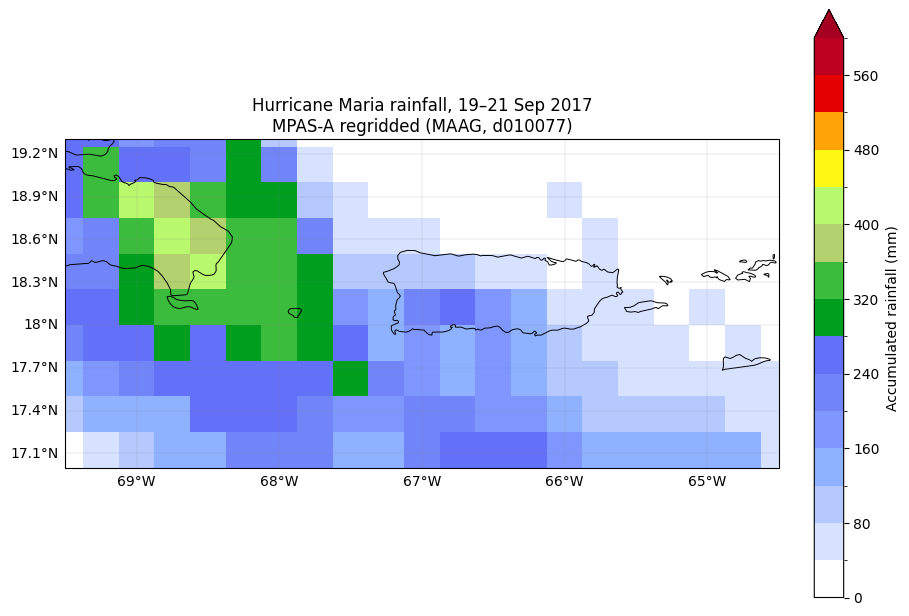

In [19]:
# Puerto Rico / NE-Caribbean window, nudged west to capture the full rainfall max
region = storm_total.sel(lat=slice(16.0, 20.0), lon=slice(-70.0, -62.0))

# Discrete precip colormap (NCL precip3_16lev), 0–600 mm
_rgb255 = [
    (255,255,255), (214,226,255), (181,201,255), (142,178,255),
    (127,150,255), (114,133,248), ( 99,112,248), (  0,158, 30),
    ( 60,188, 61), (179,209,110), (185,249,110), (255,249, 19),
    (255,163,  9), (229,  0,  0), (189,  0, 31), (165,  0, 33),
]
cmap_pr = ListedColormap(np.array(_rgb255) / 255, name="precip3_16lev")
levels  = np.arange(0, 601, 40)        # 0–600 mm (16 boundaries)
norm    = BoundaryNorm(levels, ncolors=cmap_pr.N, extend="max")

proj  = ccrs.PlateCarree()
trans = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": proj},
                       constrained_layout=True)

im = ax.pcolormesh(
    region.lon, region.lat, region.values,
    transform=trans, cmap=cmap_pr, norm=norm, shading="auto",
)
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.7)
ax.add_feature(cfeature.BORDERS.with_scale("10m"),  lw=0.5)
ax.set_extent([-69.5, -64.5, 17.0, 19.3], crs=trans)

gl = ax.gridlines(draw_labels=True, lw=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

cbar = fig.colorbar(im, ax=ax, shrink=0.85, extend="max", ticks=levels[::2],
                    label="Accumulated rainfall (mm)")
ax.set_title("Hurricane Maria rainfall, 19–21 Sep 2017\nMPAS-A regridded (MAAG, d010077)",
             fontsize=12)
plt.show()

## Summary

We accessed the MAAG Hurricane Maria (2017) MPAS-A simulation through GDEX's
kerchunk reference layer, computed the 19–21 September storm-total rainfall as
`rainc + rainnc` differenced across the window, and mapped it over Puerto Rico —
a scaled-down version of Fig. 3a of Núñez Ocasio et al. (2026). The rainfall
maximum sits just west of the island, reflecting the simulation's documented
slight westward bias in Maria's track.

:::{seealso} References and documentation
- Núñez Ocasio et al. (2026), *Advancing Weather and Climate Science in Mesoamerica and the Caribbean*, **BAMS**, [doi:10.1175/BAMS-D-25-0023.1](https://doi.org/10.1175/BAMS-D-25-0023.1)
- Dataset: [MAAG MPAS Hurricane Maria — GDEX d010077](https://gdex.ucar.edu/datasets/d010077/)
- [Variable.pdf](https://osdata.gdex.ucar.edu/web/datasets/d010077/docs/Variable.pdf) · [README.txt](https://osdata.gdex.ucar.edu/web/datasets/d010077/docs/README.txt)
- Regridding method: Núñez Ocasio et al. (2024), [doi:10.1029/2023MS004070](https://doi.org/10.1029/2023MS004070); Núñez Ocasio & Dougherty (2024), [doi:10.1029/2024GL112341](https://doi.org/10.1029/2024GL112341)

To recover the island's fine-scale, terrain-enhanced rainfall, switch to the
native-mesh `diag.*.nc` files with [`uxarray`](https://uxarray.readthedocs.io/).
:::